<a href="https://colab.research.google.com/github/AlicanKrtl/AzMhCFsEVz7fiIB0/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data = pd.read_csv("_.csv")

In [ ]:
data

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
...,...,...,...,...,...,...,...
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5


In [ ]:
data1 = data[data["Y"]==1]
data0 = data[data["Y"]==0]

In [ ]:
data0 = np.array(data0)
data1 = np.array(data1)

In [ ]:
index_C = []
index_D = []
for counta,a in enumerate(data1):
  for countb,b in enumerate(data0):
    if b[1] >= a[1] and b[2] >= a[2] and b[3] >= a[3] and b[4] >= a[4] and b[5] >= a[5] and b[6] >= a[6]:
      print(a,b,f"index a ={counta}, index b = {countb}")
      index_C.append(counta)
      index_D.append(countb)

[1 5 3 3 3 3 5] [0 5 4 3 3 3 5] index a =0, index b = 2
[1 5 3 3 3 3 5] [0 5 4 3 3 3 5] index a =0, index b = 3
[1 5 3 3 3 3 5] [0 5 3 4 5 4 5] index a =0, index b = 11
[1 5 3 3 3 3 5] [0 5 3 3 4 4 5] index a =0, index b = 48
[1 5 3 3 3 3 5] [0 5 3 5 4 5 5] index a =0, index b = 53
[1 3 2 4 3 4 4] [0 5 3 4 5 4 5] index a =4, index b = 11
[1 3 2 4 3 4 4] [0 4 2 4 4 4 4] index a =4, index b = 13
[1 3 2 4 3 4 4] [0 4 3 5 5 5 4] index a =4, index b = 14
[1 3 2 4 3 4 4] [0 4 3 5 5 5 4] index a =4, index b = 15
[1 3 2 4 3 4 4] [0 3 4 5 4 5 4] index a =4, index b = 40
[1 3 2 4 3 4 4] [0 4 2 4 4 4 4] index a =4, index b = 46
[1 3 2 4 3 4 4] [0 5 2 4 4 5 5] index a =4, index b = 47
[1 3 2 4 3 4 4] [0 5 3 5 4 5 5] index a =4, index b = 53
[1 5 1 4 3 4 5] [0 5 3 4 5 4 5] index a =5, index b = 11
[1 5 1 4 3 4 5] [0 5 2 4 4 5 5] index a =5, index b = 47
[1 5 1 4 3 4 5] [0 5 1 4 4 4 5] index a =5, index b = 51
[1 5 1 4 3 4 5] [0 5 3 5 4 5 5] index a =5, index b = 53
[1 4 2 3 3 4 4] [0 4 4 3 4 4 4] i

The samples above confuse the model because for each row pairs above, y=1 samples' values equal or lower than y=0 samples' values so I remove them at the next code cell.

In [ ]:
indexs_C, indexs_D=sorted(list(set(index_C)), reverse=True),sorted(list(set(index_D)),reverse=True)

In [ ]:
del_data1 = data1.copy()
del_data0 = data0.copy()

for i,j in zip(indexs_C,indexs_D):
  del_data1 = np.delete(del_data1,i,0)
  del_data0 = np.delete(del_data0,j,0)


In [ ]:
len(data0),len(del_data0),len(data1),len(del_data1)

(57, 17, 69, 29)

40 rows were deleted in data0 and 40 rows were deleted in data1 and the remains are assigned to del_data0 and del_data1

In [ ]:
columns = data.columns

In [ ]:
df = pd.DataFrame(np.concatenate((del_data0,del_data1),0),columns=columns)

In [ ]:
import numpy as np
import pandas as pd 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from sklearn.preprocessing import scale 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score,roc_curve
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy import stats
!pip install catboost
from catboost import CatBoostClassifier

from warnings import filterwarnings
filterwarnings('ignore')

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


     |████████████████████████████████| 76.3 MB 20 kB/s 


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       46 non-null     int64
 1   X1      46 non-null     int64
 2   X2      46 non-null     int64
 3   X3      46 non-null     int64
 4   X4      46 non-null     int64
 5   X5      46 non-null     int64
 6   X6      46 non-null     int64
dtypes: int64(7)
memory usage: 2.6 KB


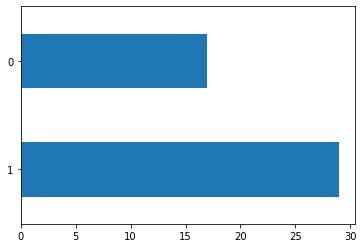

In [ ]:
df["Y"].value_counts().plot.barh();

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Y,46.0,0.630435,0.488021,0.0,0.00,1.0,1.0,1.0
X1,46.0,4.086957,1.007220,1.0,3.00,4.0,5.0,5.0
X2,46.0,2.500000,1.224745,1.0,1.25,2.0,3.0,5.0
X3,46.0,3.304348,1.262617,1.0,3.00,3.0,4.0,5.0
X4,46.0,3.826087,1.060489,1.0,3.00,4.0,5.0,5.0
X5,46.0,3.586957,1.342900,1.0,3.00,4.0,5.0,5.0
X6,46.0,4.108696,0.875043,2.0,3.00,4.0,5.0,5.0


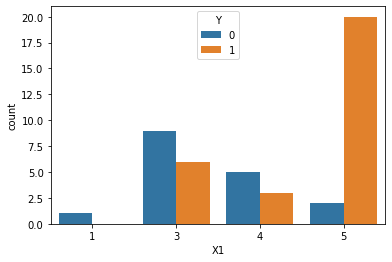

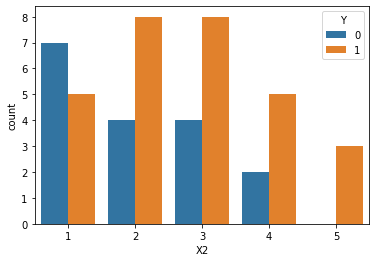

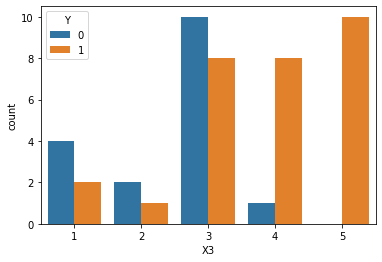

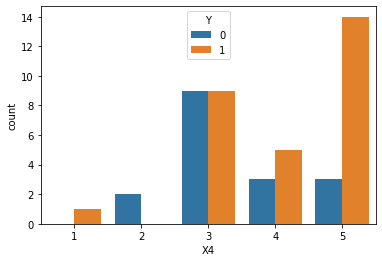

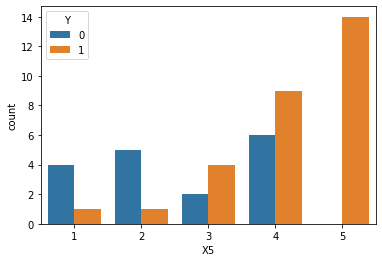

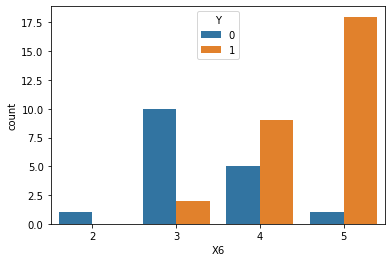

In [ ]:
for col in columns[1:]:
  sns.countplot(x=col,hue='Y',data=df)
  plt.show()

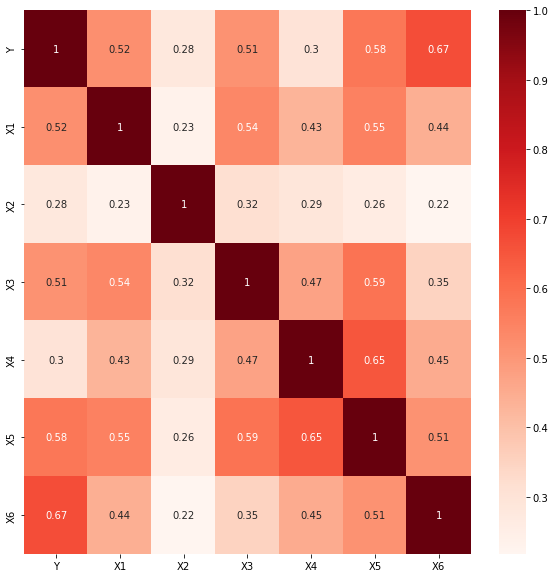

In [ ]:
plt.figure(figsize=(10,10))
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [ ]:
cor_target = abs(cor['Y']).sort_values(ascending=False)[1:]

cor_target

X6    0.668574
X5    0.575703
X1    0.518920
X3    0.511172
X4    0.302434
X2    0.278846
Name: Y, dtype: float64

Remove the samples that have abs(z_score) over 3

In [ ]:
for i in set(sorted(df[abs(stats.zscore(df))>3].index)):
  df = df.drop(i,0)

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)

**statsmodels**

In [ ]:
loj = sm.Logit(y, X)
loj_model= loj.fit()
loj_model.summary()

Optimization terminated successfully.
         Current function value: 0.481808
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                   45
Model:                          Logit   Df Residuals:                       39
Method:                           MLE   Df Model:                            5
Date:                Thu, 04 Nov 2021   Pseudo R-squ.:                  0.2597
Time:                        16:33:04   Log-Likelihood:                -21.681
converged:                       True   LL-Null:                       -29.287
Covariance Type:            nonrobust   LLR p-value:                  0.009498
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
X1            -0.6252      0.553     -1.130      0.258      -1.710       0.459
X2             0.0078      0.347      0.022      0.982      -0.672       0.688
X3             0.5015      0.417      1.202      0.229      -0.316       1.319
X4            -1.2033      0.542     -2.218      0.027      -2.266      -0.140
X5             0.9173      0.466      1.970      0.049       0.005       1.830
X6             0.7678      0.530      1.449      0.147      -0.271       1.807
==============================================================================
"""

**scikit-learn**

In [ ]:
from sklearn.linear_model import LogisticRegression
loj = LogisticRegression(solver = "liblinear" )
loj_model = loj.fit(X,y)
loj_model

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
loj_model.intercept_,loj_model.coef_

(array([-1.59053443]),
 array([[-0.21881949,  0.03830139,  0.3795673 , -0.76211732,  0.62430614,
          0.65489046]]))

**FORECAST & MODEL TUNING**

In [ ]:
y_pred = loj_model.predict(X)

In [ ]:
confusion_matrix(y, y_pred)

array([[11,  5],
       [ 1, 28]])

In [ ]:
accuracy_score(y, y_pred)

0.8666666666666667

In [ ]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79        16
           1       0.85      0.97      0.90        29

    accuracy                           0.87        45
   macro avg       0.88      0.83      0.84        45
weighted avg       0.87      0.87      0.86        45



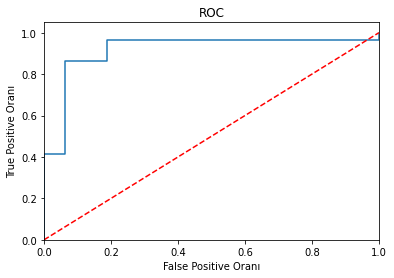

In [ ]:
logit_roc_auc = roc_auc_score(y, loj_model.predict(X))

fpr, tpr, thresholds = roc_curve(y, loj_model.predict_proba(X)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='AUC (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('ROC')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 42)


In [ ]:
loj = LogisticRegression(solver = "liblinear")
loj_model = loj.fit(X_train,y_train)
loj_model

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
accuracy_score(y_test, loj_model.predict(X_test))

0.5

In [ ]:
cross_val_score(loj_model, X_test, y_test, cv = 5).mean()

0.6333333333333333

# **Gaussian Naive Bayes**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42)

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb = GaussianNB()
nb_model = nb.fit(X_train, y_train)
nb_model

GaussianNB(priors=None, var_smoothing=1e-09)

In [ ]:
y_pred = nb_model.predict(X_test)

In [ ]:
cross_val_score(nb_model, X_test, y_test, cv = 5).mean()

1.0

# **KNN**

**MODEL & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42)

In [ ]:
knn = KNeighborsClassifier()
knn_model = knn.fit(X_train, y_train)
knn_model

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [ ]:
y_pred = knn_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.75

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.83      0.71      0.77         7

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12



# **SVC**

**Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42)

In [ ]:
svm_model = SVC(kernel = "linear").fit(X_train, y_train)

In [ ]:
svm_model

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='linear',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred)

0.6666666666666666

In [ ]:
svc_params = {"C": np.arange(1,10)}

svc = SVC(kernel = "linear")

svc_cv_model = GridSearchCV(svc,svc_params, 
                            cv = 10, 
                            n_jobs = -1, 
                            verbose = 2 )

svc_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  90 out of  90 | elapsed:    2.0s finished


GridSearchCV(cv=10, error_score=nan,
             estimator=SVC(C=1.0, break_ties=False, cache_size=200,
                           class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='scale', kernel='linear', max_iter=-1,
                           probability=False, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='deprecated', n_jobs=-1,
             param_grid={'C': array([1, 2, 3, 4, 5, 6, 7, 8, 9])},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=2)

In [ ]:
print("En iyi parametreler: " + str(svc_cv_model.best_params_))

En iyi parametreler: {'C': 1}


In [ ]:
svc_tuned = SVC(kernel = "linear", C = 8).fit(X_train, y_train)

In [ ]:
y_pred = svc_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.6666666666666666

# **RBF SVC**

## **Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42)

In [ ]:
svc_model = SVC(kernel = "rbf").fit(X_train, y_train)

In [ ]:
y_pred = svc_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.6666666666666666

**Model Tuning**

In [ ]:
svc_params = {"C": [0.0001, 0.001, 0.1, 1, 5, 10 ,50 ,100],
             "gamma": [0.0001, 0.001, 0.1, 1, 5, 10 ,50 ,100]}

In [ ]:
svc = SVC()
svc_cv_model = GridSearchCV(svc, svc_params, 
                         cv = 10, 
                         n_jobs = -1,
                         verbose = 2)

svc_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 64 candidates, totalling 640 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 606 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 640 out of 640 | elapsed:    2.2s finished


GridSearchCV(cv=10, error_score=nan,
             estimator=SVC(C=1.0, break_ties=False, cache_size=200,
                           class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='scale', kernel='rbf', max_iter=-1,
                           probability=False, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='deprecated', n_jobs=-1,
             param_grid={'C': [0.0001, 0.001, 0.1, 1, 5, 10, 50, 100],
                         'gamma': [0.0001, 0.001, 0.1, 1, 5, 10, 50, 100]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=2)

In [ ]:
print("En iyi parametreler: " + str(svc_cv_model.best_params_))

En iyi parametreler: {'C': 100, 'gamma': 0.001}


In [ ]:
svc_tuned = SVC(C = 1, gamma = 0.1).fit(X_train, y_train)

In [ ]:
y_pred = svc_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.6666666666666666

# **NEURAL NETWORKS**

**Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.30, 
                                                    random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler  

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
mlpc = MLPClassifier().fit(X_train_scaled, y_train)

In [ ]:
y_pred = mlpc.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.8571428571428571

 **Model Tuning**

In [ ]:
mlpc

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(100,), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=200,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=None, shuffle=True, solver='adam',
              tol=0.0001, validation_fraction=0.1, verbose=False,
              warm_start=False)

In [ ]:
mlpc_params = {"alpha": [0.1, 0.01, 0.02, 0.005, 0.0001,0.00001],
              "hidden_layer_sizes": [(10,10,10),
                                     (100,100,100),
                                     (100,100),
                                     (3,5), 
                                     (5, 3)],
              "solver" : ["lbfgs","adam","sgd"],
              "activation": ["relu","logistic"]}

In [ ]:
mlpc = MLPClassifier()
mlpc_cv_model = GridSearchCV(mlpc, mlpc_params, 
                         cv = 10, 
                         n_jobs = -1,
                         verbose = 2)

mlpc_cv_model.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 180 candidates, totalling 1800 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-1)]: Done 405 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 794 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1558 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 1800 out of 1800 | elapsed:  2.9min finished


GridSearchCV(cv=10, error_score=nan,
             estimator=MLPClassifier(activation='relu', alpha=0.0001,
                                     batch_size='auto', beta_1=0.9,
                                     beta_2=0.999, early_stopping=False,
                                     epsilon=1e-08, hidden_layer_sizes=(100,),
                                     learning_rate='constant',
                                     learning_rate_init=0.001, max_fun=15000,
                                     max_iter=200, momentum=0.9,
                                     n_iter_no_change=10,
                                     nesterovs_momentum=True, power_t=0.5,
                                     random_stat...
                                     validation_fraction=0.1, verbose=False,
                                     warm_start=False),
             iid='deprecated', n_jobs=-1,
             param_grid={'activation': ['relu', 'logistic'],
                         'alpha': [0.1, 0.01, 

In [ ]:
print("En iyi parametreler: " + str(mlpc_cv_model.best_params_))

En iyi parametreler: {'activation': 'logistic', 'alpha': 0.005, 'hidden_layer_sizes': (100, 100, 100), 'solver': 'lbfgs'}


In [ ]:
mlpc_tuned = MLPClassifier(activation = "relu", 
                           alpha = 0.00001, 
                           hidden_layer_sizes = (100, 100),
                          solver = 'sgd')

In [ ]:
mlpc_tuned.fit(X_train_scaled, y_train)

MLPClassifier(activation='relu', alpha=1e-05, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(100, 100), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=200,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=None, shuffle=True, solver='sgd',
              tol=0.0001, validation_fraction=0.1, verbose=False,
              warm_start=False)

In [ ]:
y_pred = mlpc_tuned.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.7142857142857143

# **CART**

**Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.30, 
                                                    random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
cart = DecisionTreeClassifier()
cart_model = cart.fit(X_train, y_train)

In [ ]:
cart_model

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [ ]:
!pip install skompiler

     |████████████████████████████████| 45 kB 1.9 MB/s 
  Created wheel for skompiler: filename=SKompiler-0.6-py3-none-any.whl size=54287 sha256=ed63e2b8741d2f6c52ff458a8b7aa85929c7ce723992ef721514e6c8c83b2b04
  Stored in directory: /root/.cache/pip/wheels/47/1c/59/b80a730f4afd2144bad854df4b167b812486c9d4c1bd4cf4c5
Successfully built skompiler


In [ ]:
from skompiler import skompile
print(skompile(cart_model.predict).to("python/code"))


((0 if x[5] <= 3.5 else (1 if x[3] <= 2.0 else 0 if x[4] <= 2.5 else 0 if x
    [1] <= 1.5 else (1 if x[4] <= 3.5 else 0) if x[0] <= 3.5 else 1) if x[2
    ] <= 3.5 else 1) if x[0] <= 4.5 else 0 if x[2] <= 1.5 else 1)



In [ ]:
y_pred = cart_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.8571428571428571

**Model Tuning**

In [ ]:
cart_model

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [ ]:
cart_grid = {"max_depth": range(1,10),
            "min_samples_split" : list(range(2,50)) }

In [ ]:
cart = tree.DecisionTreeClassifier()
cart_cv = GridSearchCV(cart, cart_grid, cv = 10, n_jobs = -1, verbose = 2)
cart_cv_model = cart_cv.fit(X_train, y_train)

Fitting 10 folds for each of 432 candidates, totalling 4320 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 668 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 4261 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 4320 out of 4320 | elapsed:   13.1s finished


In [ ]:
print("En iyi parametreler: " + str(cart_cv_model.best_params_))

En iyi parametreler: {'max_depth': 6, 'min_samples_split': 3}


#final

In [ ]:
cart = tree.DecisionTreeClassifier(max_depth = 3, min_samples_split = 3)
cart_tuned = cart.fit(X_train, y_train)

In [ ]:
y_pred = cart_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.7142857142857143

# **Random Forests**

**Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.30, 
                                                    random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier().fit(X_train, y_train)

In [ ]:
rf_model

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [ ]:
y_pred = rf_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9285714285714286

In [ ]:
rf_model

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [ ]:
rf_params = {"max_depth": [2,5,8,10],
            "max_features": [2,5,8],
            "n_estimators": [10,500,1000],
            "min_samples_split": [2,5,10]}

In [ ]:
rf_model = RandomForestClassifier()

rf_cv_model = GridSearchCV(rf_model, 
                           rf_params, 
                           cv = 10, 
                           n_jobs = -1, 
                           verbose = 2) 

In [ ]:
rf_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   30.3s
[Parallel(n_jobs=-1)]: Done 174 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 377 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 660 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 1025 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done 1080 out of 1080 | elapsed:  8.7min finished


GridSearchCV(cv=10, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False,
                                              rand

In [ ]:
print("En iyi parametreler: " + str(rf_cv_model.best_params_))

En iyi parametreler: {'max_depth': 8, 'max_features': 2, 'min_samples_split': 10, 'n_estimators': 10}


#final

In [ ]:
rf_tuned = RandomForestClassifier(max_depth = 5, 
                                  max_features = 2, 
                                  min_samples_split = 2,
                                  n_estimators = 10)

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=5, max_features=2,
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [ ]:
y_pred = rf_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.8571428571428571

In [ ]:
Importance = pd.DataFrame({"Importance": rf_tuned.feature_importances_*100},
                         index = X_train.columns)

Text(0.5, 0, 'Değişken Önem Düzeyleri')

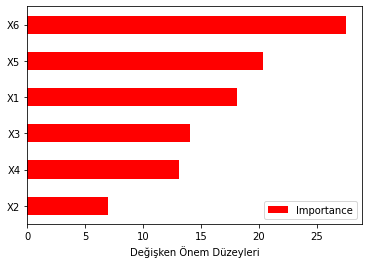

In [ ]:
Importance.sort_values(by = "Importance", 
                       axis = 0, 
                       ascending = True).plot(kind ="barh", color = "r")

plt.xlabel("Değişken Önem Düzeyleri")

# **Gradient Boosting Machines**

**Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.30, 
                                                    random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gbm_model = GradientBoostingClassifier().fit(X_train, y_train)

In [ ]:
y_pred = gbm_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7142857142857143

# **Model Tuning**

In [ ]:
gbm_model

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='deprecated',
                           random_state=None, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [ ]:
gbm_params = {"learning_rate" : [0.001, 0.01, 0.1, 0.05],
             "n_estimators": [100,500,100],
             "max_depth": [3,5,10],
             "min_samples_split": [2,5,10]}

In [ ]:
gbm = GradientBoostingClassifier()

gbm_cv = GridSearchCV(gbm, gbm_params, cv = 10, n_jobs = -1, verbose = 2)

In [ ]:
gbm_cv.fit(X_train, y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  70 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 312 tasks      | elapsed:   31.7s
[Parallel(n_jobs=-1)]: Done 718 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1080 out of 1080 | elapsed:  1.7min finished


GridSearchCV(cv=10, error_score=nan,
             estimator=GradientBoostingClassifier(ccp_alpha=0.0,
                                                  criterion='friedman_mse',
                                                  init=None, learning_rate=0.1,
                                                  loss='deviance', max_depth=3,
                                                  max_features=None,
                                                  max_leaf_nodes=None,
                                                  min_impurity_decrease=0.0,
                                                  min_impurity_split=None,
                                                  min_samples_leaf=1,
                                                  min_samples_split=2,
                                                  min_weight_fraction_leaf=0.0,
                                                  n_estimators=100,
                                                  n_iter_no_...
                 

In [ ]:
print("En iyi parametreler: " + str(gbm_cv.best_params_))

En iyi parametreler: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 500}


In [ ]:
gbm = GradientBoostingClassifier(learning_rate = 0.001, 
                                 max_depth = 3,
                                min_samples_split = 2,
                                n_estimators = 500)

In [ ]:
gbm_tuned =  gbm.fit(X_train,y_train)

In [ ]:
y_pred = gbm_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.9285714285714286

# **XGBoost**

 **Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.30, 
                                                    random_state=42)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier().fit(X_train, y_train)

In [ ]:
xgb_model

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0,
              learning_rate=0.1, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=100, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [ ]:
y_pred = xgb_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.7857142857142857

In [ ]:
xgb_model

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0,
              learning_rate=0.1, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=100, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [ ]:
xgb_params = {
        'n_estimators': [100, 500, 1000, 2000],
        'subsample': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5,6],
        'learning_rate': [0.1,0.01,0.02,0.05],
        "min_samples_split": [2,5,10]}

In [ ]:
xgb = XGBClassifier()

xgb_cv_model = GridSearchCV(xgb, xgb_params, cv = 10, n_jobs = -1, verbose = 2)

In [ ]:
xgb_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 576 candidates, totalling 5760 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 228 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 1196 tasks      | elapsed:   42.3s
[Parallel(n_jobs=-1)]: Done 2820 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 5084 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 5760 out of 5760 | elapsed:  3.5min finished


GridSearchCV(cv=10, error_score=nan,
             estimator=XGBClassifier(base_score=0.5, booster='gbtree',
                                     colsample_bylevel=1, colsample_bynode=1,
                                     colsample_bytree=1, gamma=0,
                                     learning_rate=0.1, max_delta_step=0,
                                     max_depth=3, min_child_weight=1,
                                     missing=None, n_estimators=100, n_jobs=1,
                                     nthread=None, objective='binary:logistic',
                                     random_state=0, reg_alpha=0, reg_lambda=1,
                                     scale_pos_weight=1, seed=None, silent=None,
                                     subsample=1, verbosity=1),
             iid='deprecated', n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.02, 0.05],
                         'max_depth': [3, 4, 5, 6],
                         'min_samples_split': [2, 5, 10],
 

In [ ]:
xgb_cv_model.best_params_

{'learning_rate': 0.01,
 'max_depth': 3,
 'min_samples_split': 2,
 'n_estimators': 100,
 'subsample': 0.6}

In [ ]:
xgb = XGBClassifier(learning_rate = 0.1, 
                    max_depth = 5,
                    min_samples_split = 2,
                    n_estimators = 100,
                    subsample = 0.6)

In [ ]:
xgb_tuned =  xgb.fit(X_train,y_train)

In [ ]:
y_pred = xgb_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.7142857142857143

# **CatBoost**

**Model & FORECAST**

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.30, 
                                                    random_state=42)

In [ ]:

from catboost import CatBoostClassifier

In [ ]:
cat_model = CatBoostClassifier().fit(X_train, y_train)

Learning rate set to 0.002337
0:	learn: 0.6917676	total: 46.6ms	remaining: 46.5s
1:	learn: 0.6902827	total: 47.2ms	remaining: 23.6s
2:	learn: 0.6885215	total: 47.7ms	remaining: 15.8s
3:	learn: 0.6867881	total: 48.1ms	remaining: 12s
4:	learn: 0.6848372	total: 48.6ms	remaining: 9.67s
5:	learn: 0.6834636	total: 49.1ms	remaining: 8.13s
6:	learn: 0.6817860	total: 49.5ms	remaining: 7.03s
7:	learn: 0.6798686	total: 50.1ms	remaining: 6.21s
8:	learn: 0.6783083	total: 50.5ms	remaining: 5.57s
9:	learn: 0.6764956	total: 50.9ms	remaining: 5.04s
10:	learn: 0.6745825	total: 51.4ms	remaining: 4.62s
11:	learn: 0.6729808	total: 51.8ms	remaining: 4.27s
12:	learn: 0.6715221	total: 52.3ms	remaining: 3.97s
13:	learn: 0.6694073	total: 52.7ms	remaining: 3.71s
14:	learn: 0.6674010	total: 53.2ms	remaining: 3.49s
15:	learn: 0.6656947	total: 53.6ms	remaining: 3.3s
16:	learn: 0.6638956	total: 54.1ms	remaining: 3.13s
17:	learn: 0.6623498	total: 54.5ms	remaining: 2.98s
18:	learn: 0.6608039	total: 55ms	remaining: 2.8

In [ ]:
y_pred = cat_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9285714285714286

**Model Tuning**

In [ ]:
catb_params = {
    'iterations': [200,500],
    'learning_rate': [0.01,0.05, 0.1],
    'depth': [3,5,8] }

In [ ]:
catb = CatBoostClassifier()
catb_cv_model = GridSearchCV(catb, catb_params, cv=5, n_jobs = -1, verbose = 2)
catb_cv_model.fit(X_train, y_train)
catb_cv_model.best_params_

Fitting 5 folds for each of 18 candidates, totalling 90 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    7.1s


0:	learn: 0.6864349	total: 416us	remaining: 82.9ms
1:	learn: 0.6778729	total: 1.56ms	remaining: 154ms
2:	learn: 0.6694200	total: 2.08ms	remaining: 137ms
3:	learn: 0.6653099	total: 2.58ms	remaining: 126ms
4:	learn: 0.6582265	total: 3.01ms	remaining: 118ms
5:	learn: 0.6515783	total: 3.22ms	remaining: 104ms
6:	learn: 0.6448171	total: 3.41ms	remaining: 94.1ms
7:	learn: 0.6382714	total: 3.6ms	remaining: 86.4ms
8:	learn: 0.6324831	total: 4.01ms	remaining: 85.2ms
9:	learn: 0.6281921	total: 4.43ms	remaining: 84.2ms
10:	learn: 0.6217363	total: 4.62ms	remaining: 79.4ms
11:	learn: 0.6175919	total: 4.8ms	remaining: 75.2ms
12:	learn: 0.6122916	total: 5.2ms	remaining: 74.8ms
13:	learn: 0.6062449	total: 5.48ms	remaining: 72.9ms
14:	learn: 0.6002768	total: 5.96ms	remaining: 73.6ms
15:	learn: 0.5955857	total: 6.39ms	remaining: 73.5ms
16:	learn: 0.5896607	total: 6.57ms	remaining: 70.7ms
17:	learn: 0.5858617	total: 6.76ms	remaining: 68.3ms
18:	learn: 0.5825725	total: 6.91ms	remaining: 65.8ms
19:	learn: 0

[Parallel(n_jobs=-1)]: Done  90 out of  90 | elapsed:   16.9s finished


{'depth': 3, 'iterations': 200, 'learning_rate': 0.01}

In [ ]:
catb_cv_model.best_params_

{'depth': 3, 'iterations': 200, 'learning_rate': 0.01}

In [ ]:
catb = CatBoostClassifier(iterations = 500, 
                          learning_rate = 0.01, 
                          depth = 3)

catb_tuned = catb.fit(X_train, y_train)
y_pred = catb_tuned.predict(X_test)

0:	learn: 0.6864349	total: 357us	remaining: 178ms
1:	learn: 0.6778729	total: 676us	remaining: 168ms
2:	learn: 0.6694200	total: 884us	remaining: 146ms
3:	learn: 0.6653099	total: 1.1ms	remaining: 137ms
4:	learn: 0.6582265	total: 1.3ms	remaining: 128ms
5:	learn: 0.6515783	total: 1.48ms	remaining: 122ms
6:	learn: 0.6448171	total: 1.9ms	remaining: 134ms
7:	learn: 0.6382714	total: 2.33ms	remaining: 144ms
8:	learn: 0.6324831	total: 2.74ms	remaining: 149ms
9:	learn: 0.6281921	total: 3.17ms	remaining: 155ms
10:	learn: 0.6217363	total: 3.56ms	remaining: 158ms
11:	learn: 0.6175919	total: 4.12ms	remaining: 167ms
12:	learn: 0.6122916	total: 4.56ms	remaining: 171ms
13:	learn: 0.6062449	total: 4.99ms	remaining: 173ms
14:	learn: 0.6002768	total: 5.4ms	remaining: 175ms
15:	learn: 0.5955857	total: 5.8ms	remaining: 175ms
16:	learn: 0.5896607	total: 6.2ms	remaining: 176ms
17:	learn: 0.5858617	total: 6.67ms	remaining: 179ms
18:	learn: 0.5825725	total: 7.07ms	remaining: 179ms
19:	learn: 0.5770789	total: 7.4

In [ ]:
y_pred = catb_tuned.predict(X_test)
accuracy_score(y_test, y_pred)

0.9285714285714286

# **BAGGING**

**Grid Search**

In [ ]:
from sklearn.ensemble import BaggingClassifier

In [ ]:
y = df["Y"]
X = df.drop(["Y"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.30, 
                                                    random_state=42)

In [ ]:
param_grid = {
    'max_samples': [1, 2, 3],
    'max_features':[1, 2, 3, 4],
    'n_estimators': [50, 100, 150, 200]
}


grid_search = GridSearchCV(estimator = BaggingClassifier(), param_grid = param_grid, cv = 5)

grid_search.fit(X_train, y_train)
grid_search.best_params_

{'max_features': 3, 'max_samples': 2, 'n_estimators': 50}

In [ ]:
best_grid = grid_search.best_estimator_

print("Bagging's Accuracy: ", best_grid.score(X_test, y_test))

Bagging's Accuracy:  0.6428571428571429


# **Tüm Modellerin Karşılaştırılması**

In [ ]:
modeller = [
    #knn_tuned,
    loj_model,
    svc_tuned,
    nb_model,
    mlpc_tuned,
    cart_tuned,
    rf_tuned,
    gbm_tuned,
    catb_tuned,
   
    xgb_tuned,
    best_grid
    
]# lgbm_tuned,


for model in modeller:
    isimler = model.__class__.__name__
    y_pred = model.predict(X_test)
    dogruluk = accuracy_score(y_test, y_pred)
    print("-"*28)
    print(isimler + ":" )
    print("Accuracy: {:.4%}".format(dogruluk))

----------------------------
LogisticRegression:
Accuracy: 57.1429%
----------------------------
SVC:
Accuracy: 71.4286%
----------------------------
GaussianNB:
Accuracy: 85.7143%
----------------------------
MLPClassifier:
Accuracy: 64.2857%
----------------------------
DecisionTreeClassifier:
Accuracy: 71.4286%
----------------------------
RandomForestClassifier:
Accuracy: 85.7143%
----------------------------
GradientBoostingClassifier:
Accuracy: 92.8571%
----------------------------
CatBoostClassifier:
Accuracy: 92.8571%
----------------------------
XGBClassifier:
Accuracy: 71.4286%
----------------------------
BaggingClassifier:
Accuracy: 64.2857%


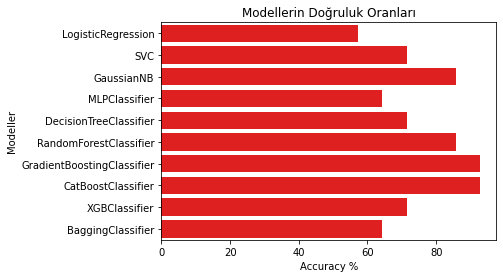

In [ ]:
sonuc = []

sonuclar = pd.DataFrame(columns= ["Modeller","Accuracy"])

for model in modeller:
    isimler = model.__class__.__name__
    y_pred = model.predict(X_test)
    dogruluk = accuracy_score(y_test, y_pred)    
    sonuc = pd.DataFrame([[isimler, dogruluk*100]], columns= ["Modeller","Accuracy"])
    sonuclar = sonuclar.append(sonuc)
    
    
sns.barplot(x= 'Accuracy', y = 'Modeller', data=sonuclar, color="r")
plt.xlabel('Accuracy %')
plt.title('Modellerin Doğruluk Oranları');    